# 03 — Feature Engineering
**TrustGraph Credit Risk Project**

Engineers 8 domain-informed features on top of the raw application data, re-trains LightGBM,
and compares AUC-ROC / KS against the notebook-02 baseline.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from scipy.stats import ks_2samp
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

ROOT       = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'notebooks' else Path(os.getcwd())
DATA_RAW   = ROOT / 'data' / 'raw'
DATA_PROC  = ROOT / 'data' / 'processed'
CHARTS_DIR = DATA_PROC / 'eda_charts'
DATA_FILE  = DATA_RAW / 'application_train.csv'

DATA_PROC.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_FILE.exists():
    raise FileNotFoundError(f"application_train.csv not found at {DATA_FILE}")
print(f"Data: {DATA_FILE}")

Data: C:\Users\krish\Downloads\TrustGraph\data\raw\application_train.csv


## 1. Load raw data

In [2]:
df = pd.read_csv(DATA_FILE)
print(f"Raw shape: {df.shape}")
print(f"Default rate: {df['TARGET'].mean():.3%}")

Raw shape: (307511, 122)
Default rate: 8.073%


## 2. Feature engineering

Each feature is computed then explained: what credit signal it captures and why it matters
especially for **thin-file borrowers** who lack bureau history.

In [3]:
fe = df.copy()

# CREDIT_INCOME_RATIO — total loan amount relative to annual income.
# High values mean the borrower is taking on debt that dwarfs their income.
# For thin-file borrowers this is often the only direct leverage signal available
# when bureau data is absent; lenders historically use 3-5x as a rule-of-thumb ceiling.
fe['CREDIT_INCOME_RATIO'] = fe['AMT_CREDIT'] / fe['AMT_INCOME_TOTAL']

# ANNUITY_INCOME_RATIO — monthly repayment obligation as a fraction of monthly income
# (both AMT_ANNUITY and AMT_INCOME_TOTAL are in annual terms here, so the ratio is
# equivalent to a debt-service-to-income ratio). Captures affordability: thin-file
# borrowers with no credit history need this ratio to be low to be considered safe.
fe['ANNUITY_INCOME_RATIO'] = fe['AMT_ANNUITY'] / fe['AMT_INCOME_TOTAL']

# CREDIT_TERM — implied loan tenor in payment periods (AMT_CREDIT / AMT_ANNUITY).
# Longer terms mean smaller periodic payments but more total interest exposure and
# higher cumulative default risk. For thin-file applicants, term length is a key
# structural risk lever lenders can observe even without bureau data.
fe['CREDIT_TERM'] = fe['AMT_CREDIT'] / fe['AMT_ANNUITY']

# DAYS_EMPLOYED_RATIO — share of lifetime (DAYS_BIRTH) spent employed (DAYS_EMPLOYED).
# Both columns are negative (days before application); the ratio is employment stability.
# A ratio close to 1 means the person has been employed for virtually their entire adult
# life — a strong stability signal for thin-file borrowers who have no credit history
# to demonstrate reliability.
# Note: DAYS_EMPLOYED = 365243 flags pensioners/unemployed — clip to avoid distortion.
employed_clean = fe['DAYS_EMPLOYED'].replace(365243, np.nan)
fe['DAYS_EMPLOYED_RATIO'] = employed_clean / fe['DAYS_BIRTH']

# EXT_SOURCE_MEAN — average of the three external credit bureau scores.
# These are the single strongest individual predictors in the dataset. For thin-file
# borrowers, at least one source often exists even without a full bureau file; the
# mean pools them to reduce noise and handle partial missingness gracefully.
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
fe['EXT_SOURCE_MEAN'] = fe[ext_cols].mean(axis=1)

# EXT_SOURCE_MIN — the lowest individual external score.
# The worst-case score captures tail risk that the mean can obscure. A borrower with
# one very low score among otherwise good scores may carry hidden risk; thin-file
# borrowers often have one data-rich source and two missing ones, so the minimum
# isolates the only observed score when only one exists.
fe['EXT_SOURCE_MIN'] = fe[ext_cols].min(axis=1)

# INCOME_PER_PERSON — household income divided by family size.
# A borrower supporting many dependants on a fixed income has less disposable cash
# for debt service. This is especially informative for thin-file borrowers whose
# income may look adequate individually but is stretched thin per household member.
fe['INCOME_PER_PERSON'] = fe['AMT_INCOME_TOTAL'] / fe['CNT_FAM_MEMBERS'].replace(0, np.nan)

# FLAG_MISSING_EXT — binary flag: 1 if ANY of the three EXT_SOURCE values is NaN.
# Missing external scores are themselves a signal of thin-file status; bureaus lack
# data on this applicant. Models can use this flag to explicitly learn that 'no
# bureau score available' is informative, rather than treating imputed fill-values
# as real observations.
fe['FLAG_MISSING_EXT'] = fe[ext_cols].isnull().any(axis=1).astype(int)

engineered = [
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM',
    'DAYS_EMPLOYED_RATIO', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN',
    'INCOME_PER_PERSON', 'FLAG_MISSING_EXT',
]

print(f"Engineered features created: {engineered}")
fe[engineered].describe().round(4)

Engineered features created: ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'DAYS_EMPLOYED_RATIO', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'INCOME_PER_PERSON', 'FLAG_MISSING_EXT']


,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_TERM,DAYS_EMPLOYED_RATIO,EXT_SOURCE_MEAN,EXT_SOURCE_MIN,INCOME_PER_PERSON,FLAG_MISSING_EXT
count,307511.0000,307499.0000,307499.0000,252137.0000,307339.0000,307339.0000,3.075090e+05,307511.0000
mean,3.9576,0.1809,21.6123,0.1569,0.5093,0.3996,9.310588e+04,0.6436
std,2.6897,0.0946,7.8238,0.1335,0.1498,0.1874,1.013734e+05,0.4789
min,0.0048,0.0002,8.0367,-0.0000,0.0000,0.0000,2.812500e+03,0.0000
25%,2.0187,0.1148,15.6145,0.0561,0.4136,0.2540,4.725000e+04,0.0000
50%,3.2651,0.1628,20.0000,0.1187,0.5245,0.4032,7.500000e+04,1.0000
75%,5.1599,0.2291,27.1000,0.2192,0.6228,0.5530,1.125000e+05,1.0000
max,84.7368,1.8760,45.3051,0.7288,0.8789,0.8789,3.900000e+07,1.0000


### Correlation of engineered features with TARGET

In [4]:
corr_with_target = fe[engineered + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()
print(corr_with_target.round(4).to_string())

EXT_SOURCE_MEAN        -0.2221
EXT_SOURCE_MIN         -0.1853
DAYS_EMPLOYED_RATIO    -0.0680
CREDIT_TERM            -0.0321
CREDIT_INCOME_RATIO    -0.0077
INCOME_PER_PERSON      -0.0066
ANNUITY_INCOME_RATIO    0.0143
FLAG_MISSING_EXT        0.0212


## 3. Preprocessing (same pipeline as notebook 02)

In [5]:
y = fe['TARGET']
X = fe.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f"Total features: {X.shape[1]}  (numeric: {len(num_cols)}, categorical: {len(cat_cols)})")
print(f"  of which engineered: {len(engineered)}")

X_proc = X.copy()
for col in num_cols:
    X_proc[col] = X_proc[col].fillna(X_proc[col].median())

le = LabelEncoder()
for col in cat_cols:
    X_proc[col] = X_proc[col].fillna('MISSING')
    X_proc[col] = le.fit_transform(X_proc[col].astype(str))

print(f"Nulls remaining: {X_proc.isnull().sum().sum()}")

Total features: 128  (numeric: 112, categorical: 16)
  of which engineered: 8


Nulls remaining: 0


## 4. Train / test split (80/20 stratified, same seed)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_proc, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (246008, 128)  Test: (61503, 128)


## 5. Train LightGBM (same params as notebook 02)

In [7]:
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)
print("Training complete.")

[100]	valid_0's binary_logloss: 0.571408


[200]	valid_0's binary_logloss: 0.556555


[300]	valid_0's binary_logloss: 0.546602


[400]	valid_0's binary_logloss: 0.53733


[500]	valid_0's binary_logloss: 0.528852
Training complete.


## 6. Evaluate and compare vs notebook-02 baseline

In [8]:
def ks_statistic(y_true, y_prob):
    stat, _ = ks_2samp(y_prob[y_true == 1], y_prob[y_true == 0])
    return stat

prob = lgbm.predict_proba(X_test)[:, 1]
auc_new = roc_auc_score(y_test, prob)
ks_new  = ks_statistic(y_test.values, prob)

# Baseline numbers from 02_baseline (loaded if available, otherwise hardcoded)
baseline_path = DATA_PROC / 'baseline_results.csv'
if baseline_path.exists():
    base_df  = pd.read_csv(baseline_path)
    lgbm_row = base_df[base_df['Model'] == 'LightGBM'].iloc[0]
    auc_base = lgbm_row['AUC_ROC']
    ks_base  = lgbm_row['KS_Statistic']
else:
    auc_base, ks_base = 0.7611, 0.3908   # from notebook 02

results = pd.DataFrame({
    'Model':        ['LightGBM Baseline (02)', 'LightGBM + Engineered (03)'],
    'AUC_ROC':      [round(auc_base, 4), round(auc_new, 4)],
    'KS_Statistic': [round(ks_base,  4), round(ks_new,  4)],
    'AUC_Delta':    [0.0, round(auc_new - auc_base, 4)],
    'KS_Delta':     [0.0, round(ks_new  - ks_base,  4)],
})

print(results.to_string(index=False))

                     Model  AUC_ROC  KS_Statistic  AUC_Delta  KS_Delta
    LightGBM Baseline (02)   0.7611        0.3908     0.0000    0.0000
LightGBM + Engineered (03)   0.7689        0.4032     0.0078    0.0124


## 7. Save comparison table

In [9]:
out_path = DATA_PROC / 'feature_results.csv'
results.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
results

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\feature_results.csv


,Model,AUC_ROC,KS_Statistic,AUC_Delta,KS_Delta
0,LightGBM Baseline (02),0.7611,0.3908,0.0000,0.0000
1,LightGBM + Engineered (03),0.7689,0.4032,0.0078,0.0124


## 8. Feature importance — top 20

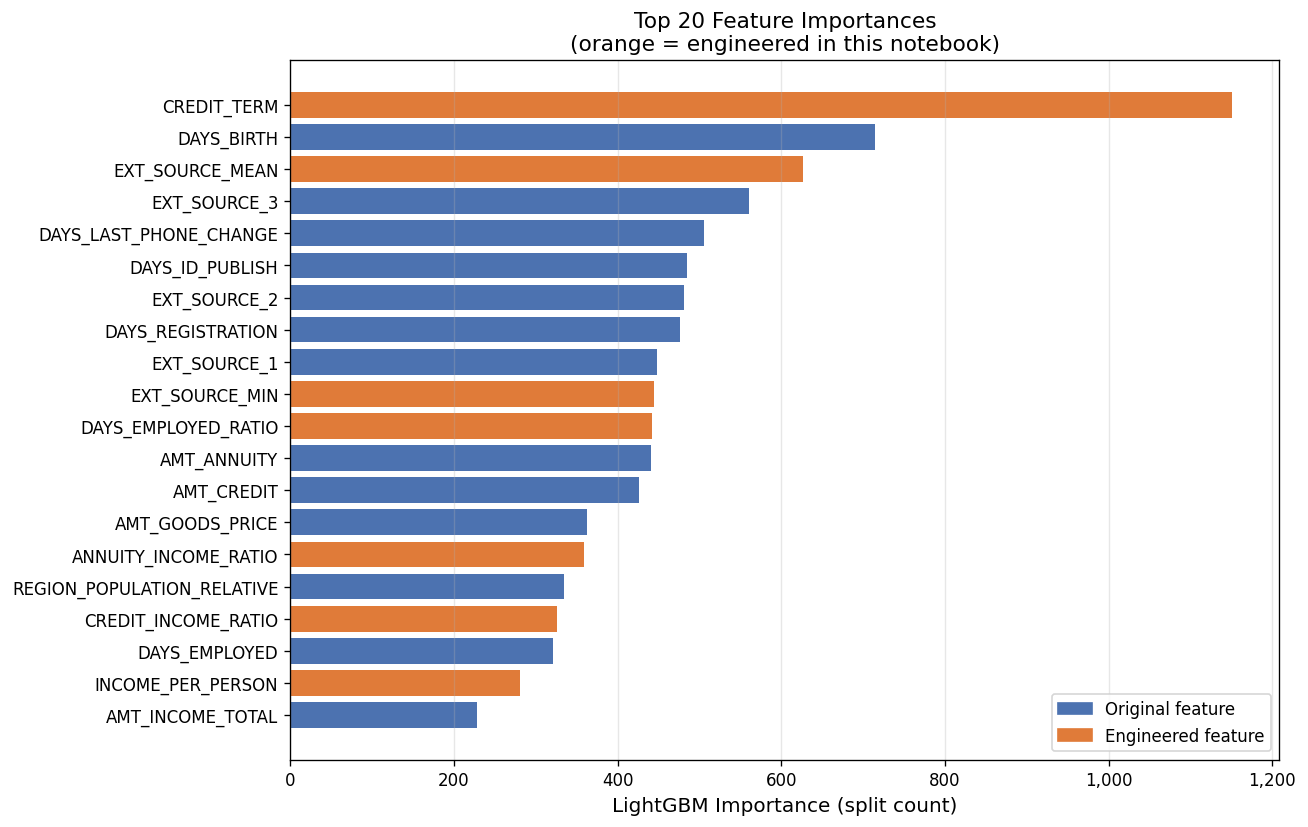

Saved: C:\Users\krish\Downloads\TrustGraph\data\processed\eda_charts\feature_importance.png

Engineered features in top 20:
             feature  importance
         CREDIT_TERM        1151
     EXT_SOURCE_MEAN         627
      EXT_SOURCE_MIN         445
 DAYS_EMPLOYED_RATIO         442
ANNUITY_INCOME_RATIO         359
 CREDIT_INCOME_RATIO         326
   INCOME_PER_PERSON         281


In [10]:
importance = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': lgbm.feature_importances_,
}).sort_values('importance', ascending=False).head(20)

# Tag engineered features for visual highlight
importance['is_engineered'] = importance['feature'].isin(engineered)
colors = ['#e07b39' if e else '#4c72b0' for e in importance['is_engineered']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(importance['feature'][::-1], importance['importance'][::-1], color=colors[::-1])

ax.set_xlabel('LightGBM Importance (split count)', fontsize=12)
ax.set_title('Top 20 Feature Importances\n(orange = engineered in this notebook)', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#4c72b0', label='Original feature'),
    Patch(color='#e07b39', label='Engineered feature'),
], loc='lower right', fontsize=10)

plt.tight_layout()
imp_path = CHARTS_DIR / 'feature_importance.png'
plt.savefig(imp_path, bbox_inches='tight')
plt.show()
print(f"Saved: {imp_path}")
print()
print("Engineered features in top 20:")
print(importance[importance['is_engineered']][['feature','importance']].to_string(index=False))

## 9. Save full processed feature matrix

In [11]:
# Attach TARGET and SK_ID_CURR back for downstream notebooks
out_df = X_proc.copy()
out_df.insert(0, 'SK_ID_CURR', df['SK_ID_CURR'].values)
out_df['TARGET'] = y.values

feat_path = DATA_PROC / 'features_train.csv'
out_df.to_csv(feat_path, index=False)
print(f"Saved feature matrix: {feat_path}")
print(f"Shape: {out_df.shape}  |  Columns: {out_df.shape[1]}")

Saved feature matrix: C:\Users\krish\Downloads\TrustGraph\data\processed\features_train.csv
Shape: (307511, 130)  |  Columns: 130


## 10. Summary

In [12]:
delta_auc = auc_new - auc_base
delta_ks  = ks_new  - ks_base

print("=" * 52)
print("  FEATURE ENGINEERING — RESULTS")
print("=" * 52)
print(f"  Baseline  AUC: {auc_base:.4f}   KS: {ks_base:.4f}")
print(f"  With FE   AUC: {auc_new:.4f}   KS: {ks_new:.4f}")
print(f"  Delta     AUC: {delta_auc:+.4f}   KS: {delta_ks:+.4f}")
print("=" * 52)
print()
print("Outputs:")
print(f"  data/processed/feature_results.csv")
print(f"  data/processed/features_train.csv")
print(f"  data/processed/eda_charts/feature_importance.png")

  FEATURE ENGINEERING — RESULTS
  Baseline  AUC: 0.7611   KS: 0.3908
  With FE   AUC: 0.7689   KS: 0.4032
  Delta     AUC: +0.0078   KS: +0.0124

Outputs:
  data/processed/feature_results.csv
  data/processed/features_train.csv
  data/processed/eda_charts/feature_importance.png
